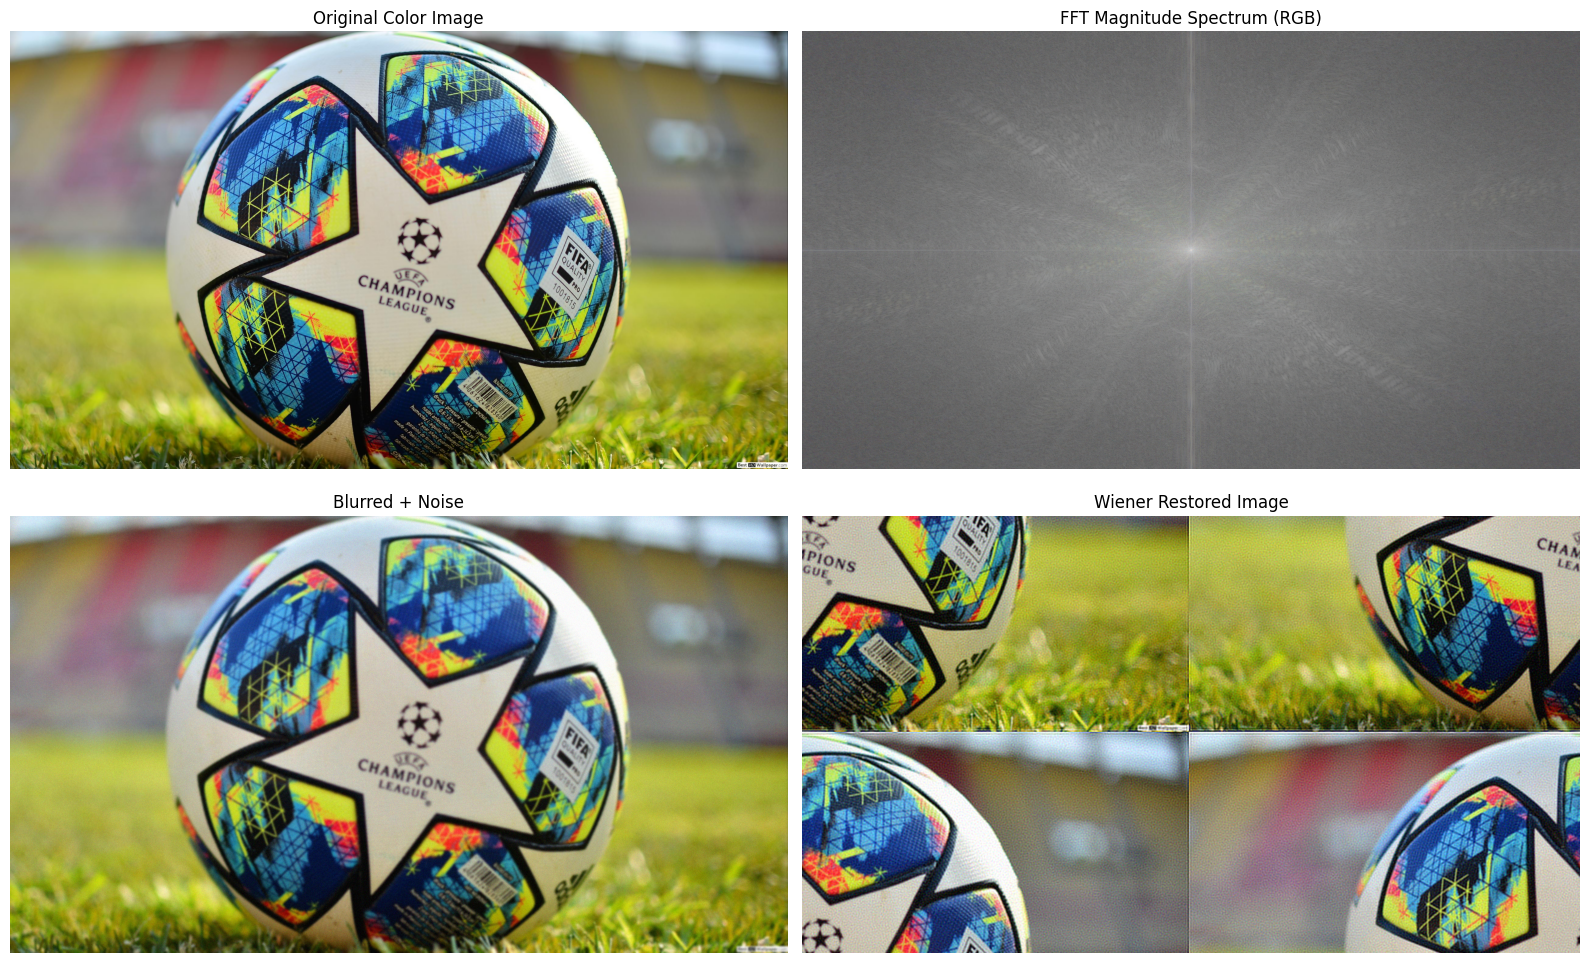

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

filename = ('/content/wp9770341.jpg')

img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

# ===============================
# 2D Fast Fast Transformation (Per Channel)
# ===============================
fft_magnitude = np.zeros_like(img)

for c in range(3):
    F = np.fft.fft2(img[:,:,c])
    F_shift = np.fft.fftshift(F)
    fft_magnitude[:,:,c] = np.log(1 + np.abs(F_shift))

# Normalize for display
fft_magnitude = fft_magnitude / np.max(fft_magnitude)

# ===============================
# Gaussian PSF
# ===============================
def gaussian_kernel(size=15, sigma=3):
    ax = np.arange(-size//2 + 1., size//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

kernel = gaussian_kernel(15, 3)

# ===============================
# Blur + Add Noise
# ===============================
blurred = np.zeros_like(img)
noisy_blurred = np.zeros_like(img)

for c in range(3):
    blurred[:,:,c] = cv2.filter2D(img[:,:,c], -1, kernel)
    noise = np.random.normal(0, 10, img[:,:,c].shape)
    noisy_blurred[:,:,c] = blurred[:,:,c] + noise

# ===============================
# Wiener Filter (Per Channel)
# ===============================
def wiener_filter(channel, kernel, K=0.01):
    rows, cols = channel.shape
    G = np.fft.fft2(channel)

    kernel_padded = np.zeros((rows, cols))
    kh, kw = kernel.shape
    kernel_padded[:kh, :kw] = kernel
    kernel_padded = np.fft.ifftshift(kernel_padded)

    H = np.fft.fft2(kernel_padded)
    H_conj = np.conj(H)

    F_hat = (H_conj / (np.abs(H)**2 + K)) * G
    f_hat = np.fft.ifft2(F_hat)

    return np.abs(f_hat)

restored = np.zeros_like(img)

for c in range(3):
    restored[:,:,c] = wiener_filter(noisy_blurred[:,:,c], kernel)

# Clip for display
img_disp = np.clip(img, 0, 255).astype(np.uint8)
noisy_disp = np.clip(noisy_blurred, 0, 255).astype(np.uint8)
restored_disp = np.clip(restored, 0, 255).astype(np.uint8)

# ===============================
# Display Results
# ===============================
plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plt.imshow(img_disp)
plt.title("Original Color Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(fft_magnitude)
plt.title("FFT Magnitude Spectrum (RGB)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(noisy_disp)
plt.title("Blurred + Noise")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(restored_disp)
plt.title("Wiener Restored Image")
plt.axis('off')

plt.tight_layout()
plt.show()